In [1]:
from langgraph.graph import MessagesState
from groq import Groq
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver
load_dotenv()

True

True

In [2]:
model = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.3
)

In [3]:
class ChatState(MessagesState):
    summary: str

In [4]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = model.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [5]:
def chat_node(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])

    print(messages)

    response = model.invoke(messages)
    return {"messages": [response]}

In [6]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 2

In [7]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")



In [8]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

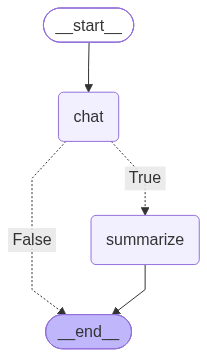

In [9]:
graph

In [10]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [11]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [12]:
run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='6a0b799e-8d2f-469a-9956-b2b11c3bff55')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : ## Quantum Physics – A Quick‑but‑Comprehensive Overview  

Below is a compact ro


In [13]:
run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='6a0b799e-8d2f-469a-9956-b2b11c3bff55'), AIMessage(content='## Quantum Physics – A Quick‑but‑Comprehensive Overview  \n\nBelow is a compact roadmap that takes you from the **historical roots** of quantum theory to the **modern frontiers** and **practical applications**. Feel free to dive deeper into any section, or let me know which part you’d like to explore in more detail!\n\n---\n\n### 1️⃣ Why “Quantum”?  What Was Wrong with Classical Physics?\n\n| Classical Picture | Quantum Reality |\n|-------------------|-----------------|\n| **Deterministic** – given initial conditions, the future is fixed. | **Probabilistic** – only probabilities for measurement outcomes. |\n| **Continuous** variables (e.g., energy, angular momentum). | **Quantized** – many observables come in discrete “chunks”. |\n| **Point particles** with well‑defined trajectories. | **Wave‑particle duality** – particles exhibit wave‑like

APIStatusError: Error code: 413 - {'error': {'message': 'Request too large for model `openai/gpt-oss-120b` in organization `org_01j5mft6sxe6k8fb9ftj2ekx12` service tier `on_demand` on tokens per minute (TPM): Limit 8000, Requested 8090, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

In [ ]:
run_turn('What are some of Einstien"s famous work')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='df473619-8d6e-4f11-bb29-e8745cb95f8b'), AIMessage(content='Quantum physics, also known as quantum mechanics, is the branch of physics that describes the behavior of matter and energy on the smallest scales of atoms and subatomic particles. It is a fundamental theory in physics that explains the behavior of particles and waves at the atomic and subatomic levels.\n\nOne of the key principles of quantum physics is that particles can exist in multiple states at the same time, a concept known as superposition. Another important principle is the idea of quantum entanglement, where particles become correlated in a way that their quantum states are intertwined, even when separated by large distances.\n\nQuantum physics has led to the development of many technologies, such as quantum computing and quantum cryptography, that have the potential to revolutionize the way we process information and secure commun

In [39]:
run_turn('Explain special theory of relativity')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='df473619-8d6e-4f11-bb29-e8745cb95f8b'), AIMessage(content='Quantum physics, also known as quantum mechanics, is the branch of physics that describes the behavior of matter and energy on the smallest scales of atoms and subatomic particles. It is a fundamental theory in physics that explains the behavior of particles and waves at the atomic and subatomic levels.\n\nOne of the key principles of quantum physics is that particles can exist in multiple states at the same time, a concept known as superposition. Another important principle is the idea of quantum entanglement, where particles become correlated in a way that their quantum states are intertwined, even when separated by large distances.\n\nQuantum physics has led to the development of many technologies, such as quantum computing and quantum cryptography, that have the potential to revolutionize the way we process information and secure commun